In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [3]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles;

In [4]:
# Pyplot rcparams
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["text.usetex"] = false;
mlines = pyimport("matplotlib").lines
# General method to give red-green-blue values for plotting
rgb(x, y, z) = [x, y, z] ./ 255

rgb (generic function with 1 method)

In [5]:
bn22bc_dir="./BN22BC"
bn22bc_buckled_dir="./BN22BC_Buckled"
bn33bc_dir="./BN33BC"
bn33bc_buckled_dir="./BN33BC_Buckled"
bn44bc_dir="./BN44BC"
bn44bc_buckled_dir="./BN44BC_Buckled"
bn22nc_dir="./BN22NC"
bn33nc_dir="./BN33NC"
bn44nc_dir="./BN44NC"
Ag_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/3Dnew"
Argentene_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/2Dnew"
graphene_dir = "./Graphene";

In [9]:
qs22nc, plasmon22nc, confinements22nc = [x for x in eachcol(np.loadtxt("$bn22nc_dir/Wannier/Plasmon.txt"))];
qs33nc, plasmon33nc, confinements33nc = [x for x in eachcol(np.loadtxt("$bn33nc_dir/Wannier/Plasmon.txt"))];
qs44nc, plasmon44nc, confinements44nc = [x for x in eachcol(np.loadtxt("$bn44nc_dir/Wannier/Plasmon.txt"))];

qs22bc, plasmon22bc, confinements22bc = [x for x in eachcol(np.loadtxt("$bn22bc_dir/Wannier/Plasmon.txt"))];
qs33bc, plasmon33bc, confinements33bc = [x for x in eachcol(np.loadtxt("$bn33bc_dir/Wannier/Plasmon.txt"))];
qs44bc, plasmon44bc, confinements44bc = [x for x in eachcol(np.loadtxt("$bn44bc_dir/Wannier/Plasmon.txt"))];

graphene_qs, graphene_plasmon, graphene_confinements = [x for x in eachcol(np.loadtxt("$graphene_dir/Plasmon.txt"))];

In [10]:
bn22bc_intra_qs, bn22bc_intra_plasmon, _, _ = [collect(x) for x in eachcol(np.loadtxt(bn22bc_dir*"/Plasmons/plasmon.txt"))];
bn33bc_intra_qs, bn33bc_intra_plasmon, _, _ = [collect(x) for x in eachcol(np.loadtxt(bn33bc_dir*"/Plasmons/plasmon.txt"))];
bn44bc_intra_qs, bn44bc_intra_plasmon, _, _ = [collect(x) for x in eachcol(np.loadtxt(bn44bc_dir*"/Plasmons/plasmon.txt"))];

bn22nc_intra_qs, bn22nc_intra_plasmon, _, _ = [collect(x) for x in eachcol(np.loadtxt(bn22nc_dir*"/Plasmons/plasmon.txt"))];
bn33nc_intra_qs, bn33nc_intra_plasmon, _, _ = [collect(x) for x in eachcol(np.loadtxt(bn33nc_dir*"/Plasmons/plasmon.txt"))];
bn44nc_intra_qs, bn44nc_intra_plasmon, _, _ = [collect(x) for x in eachcol(np.loadtxt(bn44nc_dir*"/Plasmons/plasmon.txt"))];

In [24]:
max22bc = maximum(plasmon22bc)
max33bc = maximum(plasmon33bc)
max44bc = maximum(plasmon44bc)

max22nc = maximum(plasmon22nc)
max33nc = maximum(plasmon33nc)
max44nc = maximum(plasmon44nc)

println("BN22BC Max:",  max22bc)
println("BN33BC Max:",  max33bc)
println("BN44BC Max:",  max44bc)
println("BN22NC Max:",  max22nc)
println("BN33NC Max:",  max33nc)
println("BN44NC Max:",  max44nc)

BN22BC Max:0.8097084702400599
BN33BC Max:0.2867850231741476
BN44BC Max:0.1727303017164614
BN22NC Max:0.7383838383838384
BN33NC Max:0.3084959013661931
BN44NC Max:0.19998887648097619


In [7]:
omegas,  tau22nc_allen = [x for x in eachcol(np.loadtxt("$bn22nc_dir/Plasmons/tau_allen.txt"))];
_ , tau33nc_allen = [x for x in eachcol(np.loadtxt("$bn33nc_dir/Plasmons/tau_allen.txt"))];
_ , tau44nc_allen = [x for x in eachcol(np.loadtxt("$bn44nc_dir/Plasmons/tau_allen.txt"))];

_ , tau22bc_allen = [x for x in eachcol(np.loadtxt("$bn22bc_dir/Plasmons/tau_allen.txt"))];
_ , tau33bc_allen = [x for x in eachcol(np.loadtxt("$bn33bc_dir/Plasmons/tau_allen.txt"))];
_ , tau44bc_allen = [x for x in eachcol(np.loadtxt("$bn44bc_dir/Plasmons/tau_allen.txt"))];

_, _, tau_graphene_shankar, tau_graphene_allen = [x for x in eachcol(np.loadtxt("$graphene_dir/tau.txt"))];
_, _, tau_Ag_shankar, tau_Ag_allen = [x for x in eachcol(np.loadtxt("$Ag_dir/tau.txt"))];
_, _, tau_argentene_shankar, tau_argentene_allen = [x for x in eachcol(np.loadtxt("$Argentene_dir/tau.txt"))];

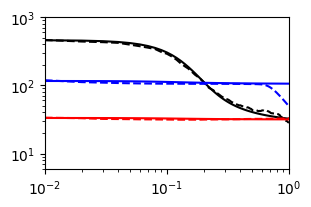

In [17]:
#Supp Figure 4
cm = 1/2.54
figure(figsize=(8*cm, 5*cm))
omegas = collect(0.01:0.01:1)
loglog(omegas, tau_graphene_shankar, color="black")
loglog(omegas, tau_graphene_allen, linestyle="dashed", color="black")
loglog(omegas, tau_Ag_shankar, color="red")
loglog(omegas, tau_Ag_allen, linestyle="dashed", color="red")
loglog(omegas, tau_argentene_shankar, color="blue")
loglog(omegas, tau_argentene_allen, linestyle="dashed", color="blue")

ylim(6, 1000)
xlim(0.01, 1)
savefig("Allen_v_Shankar.pdf")

In [18]:
# Figure 2

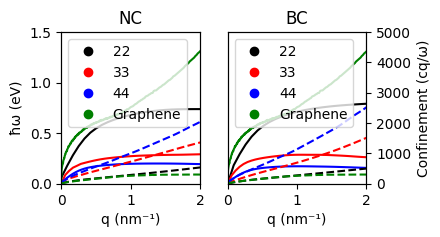

In [39]:
#Legend Properties
cm = 1/2.54
lab22 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="black");
lab33 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="red");
lab44 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="blue");
labgraphene = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="green");

figure(figsize=(10*cm, 5*cm))
subplot(1, 2, 1)
ylim(0, 1.5)
ylabel("ħω (eV)")
plot(qs22nc*10, plasmon22nc, color="black")
plot(qs33nc*10, plasmon33nc, color="red")
plot(qs44nc*10, plasmon44nc, color="blue")
plot(graphene_qs*10, graphene_plasmon, color="green")

xlabel("q (nm⁻¹)")
xlim(0, 2)
twinx()

plot(qs22nc*10, confinements22nc, color="black", linestyle="dashed", label="22")
plot(qs33nc*10, confinements33nc, color="red", linestyle="dashed", label="33")
plot(qs44nc*10, confinements44nc, color="blue", linestyle="dashed", label="44")
plot(graphene_qs*10, graphene_confinements, color="green", linestyle="dashed", label="labgraphene")

ylim(0, 5000)
yticks([])
legend(handles = [lab22, lab33, lab44, labgraphene], labels = ["22", "33", "44", "Graphene"])
title("NC")

subplot(1, 2, 2)
yticks([])
ylim(0, 1.5)
plot(qs22bc*10, plasmon22bc, color="black")
plot(qs33bc*10, plasmon33bc, color="red")
plot(qs44bc*10, plasmon44bc, color="blue")
plot(graphene_qs*10, collect(graphene_plasmon), color="green")

xlabel("q (nm⁻¹)")
xlim(0, 2)
twinx()
plot(qs22bc*10, confinements22bc, color="black", linestyle="dashed", label="22")
plot(qs33bc*10, confinements33bc, color="red", linestyle="dashed", label="33")
plot(qs44bc*10, confinements44bc, color="blue", linestyle="dashed", label="44")
plot(graphene_qs*10, graphene_confinements, color="green", linestyle="dashed", label="graphene")

ylim(0, 5000)
ylabel("Confinement (cq/ω)")
title("BC")

legend(handles = [lab22, lab33, lab44, labgraphene], labels = ["22", "33", "44", "Graphene"])
savefig("AllPlasmons.pdf")

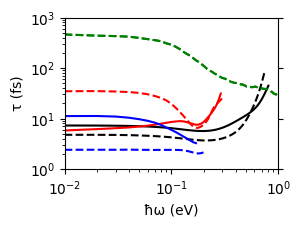

In [40]:
lab22 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="black");
lab33 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="red");
lab44 = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="blue");
labAg = mlines.Line2D(Float64[], Float64[], marker="o", linestyle="None", color="green");

figure(figsize=(7*cm, 5*cm))
loglog(omegas[1:argmin(abs.(max22nc .- omegas))], tau22nc_allen[1:argmin(abs.(max22nc .- omegas))], color="black", linestyle="dashed")
loglog(omegas[1:argmin(abs.(max33nc .- omegas))], tau33nc_allen[1:argmin(abs.(max33nc .- omegas))], color="red", linestyle="dashed")
loglog(omegas[1:argmin(abs.(max44nc .- omegas))], tau44nc_allen[1:argmin(abs.(max44nc .- omegas))], color="blue", linestyle="dashed")
loglog(omegas, collect(tau_graphene_allen), color="green", linestyle="dashed")

xlabel("ħω (eV)")
ylabel("τ (fs)")
xlim(0.01, 1)
loglog(omegas[1:argmin(abs.(max22bc .- omegas))], tau22bc_allen[1:argmin(abs.(max22bc .- omegas))], color="black", linestyle="solid")
loglog(omegas[1:argmin(abs.(max33bc .- omegas))], tau33bc_allen[1:argmin(abs.(max33bc .- omegas))], color="red", linestyle="solid")
loglog(omegas[1:argmin(abs.(max44bc .- omegas))], tau44bc_allen[1:argmin(abs.(max44bc .- omegas))], color="blue", linestyle="solid")
loglog(omegas, tau_graphene_allen, color="green", linestyle="dashed")

ylim(1, 1000)
xlim(0.01, 1)
tick_params(right=true)
xlabel("ħω (eV)")
savefig("Alltaus_allen.pdf")

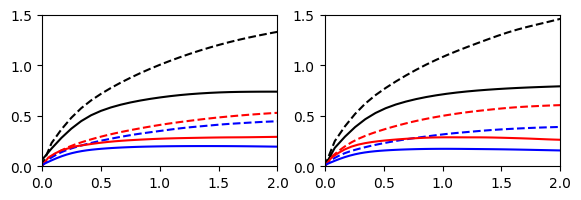

In [12]:
# Supplemental Figure 3
cm = 1/2.54
figure(figsize=(17*cm, 5*cm))
subplot(1, 2, 2)
plot(bn22bc_intra_qs*10, bn22bc_intra_plasmon, color="black", linestyle="dashed")
plot(bn33bc_intra_qs*10, bn33bc_intra_plasmon, color="red", linestyle="dashed")
plot(bn44bc_intra_qs*10, bn44bc_intra_plasmon, color="blue", linestyle="dashed")

plot(qs22bc*10, plasmon22bc, color="black")
plot(qs33bc*10, plasmon33bc, color="red")
plot(qs44bc*10, plasmon44bc, color="blue")


ylim(0, 1.5)
xlim(0, 2)

subplot(1, 2, 1)

plot(bn22nc_intra_qs*10, bn22nc_intra_plasmon, color="black", linestyle="dashed")
plot(bn33nc_intra_qs*10, bn33nc_intra_plasmon, color="red", linestyle="dashed")
plot(bn44nc_intra_qs*10, bn44nc_intra_plasmon, color="blue", linestyle="dashed")

plot(qs22nc*10, plasmon22nc, color="black")
plot(qs33nc*10, plasmon33nc, color="red")
plot(qs44nc*10, plasmon44nc, color="blue")

ylim(0, 1.5)
xlim(0, 2)
savefig("IntraVsInter.pdf")